In [87]:
# Import all required libraries
import pandas as pd
import numpy as np
import pingouin as pg
from pathlib import Path
from glob import glob
from scipy import stats
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op
import re

In [103]:
# Setup directories and plotting theme
data_dir = "./dset"
#raw_annot_dir = op.join(data_dir, "annotations")
deriv_dir = op.join(data_dir, "derivatives")
raw_annot_dir = op.join(deriv_dir, "annotations-anonymized")


# # Create directories
# OUT_DIR.mkdir(parents=True, exist_ok=True)
# FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Configure plotting theme
sns.set_theme(style="darkgrid")

# Define colors for consistent plotting
colors = ['#CF9397', "#606933", '#E5D28E', '#715958', '#AC9B74', '#8c564b', '#e377c2', '#BCB5BB']

In [ ]:
episode_numbers = [1, 2, 3, 4]
run_numbers = range(0, 8)

episode_csvs = {}

for ep_num in episode_numbers:
    episode_key = f"S01E{ep_num:02d}"
    episode_dir = op.join(raw_annot_dir, episode_key)

    run_csvs = {}
    for i in run_numbers:
        run_key = f"R0{i}"
        csv_pattern = op.join(episode_dir, f"{episode_key}{run_key}*.csv")
        csv_files = sorted(glob(csv_pattern))
        if csv_files:
            run_csvs[run_key] = csv_files

    episode_csvs[episode_key] = run_csvs

    print(f"{episode_key}: {len(run_csvs)} runs with CSVs")
    for run_key, files in run_csvs.items():
        print(f"  {run_key}: {len(files)} CSV files")
        for file_path in files:
            rater_df = pd.read_csv(file_path)
            print(f"    {op.basename(file_path)} -> {rater_df.shape}")
            
    print()

S01E01: 6 runs with CSVs
  R01: 4 CSV files
    S01E01R01_002.csv -> (334, 3)
    S01E01R01_003.csv -> (334, 3)
    S01E01R01_005.csv -> (334, 3)
    S01E01R01_008.csv -> (334, 3)
  R02: 5 CSV files
    S01E01R02_001.csv -> (276, 3)
    S01E01R02_002.csv -> (276, 3)
    S01E01R02_003.csv -> (276, 3)
    S01E01R02_004.csv -> (276, 3)
    S01E01R02_008.csv -> (276, 3)
  R03: 3 CSV files
    S01E01R03_004.csv -> (275, 3)
    S01E01R03_005.csv -> (275, 3)
    S01E01R03_006.csv -> (275, 3)
  R04: 2 CSV files
    S01E01R04_001.csv -> (286, 3)
    S01E01R04_008.csv -> (286, 3)
  R05: 4 CSV files
    S01E01R05_003.csv -> (312, 3)
    S01E01R05_005.csv -> (312, 3)
    S01E01R05_006.csv -> (312, 3)
    S01E01R05_008.csv -> (312, 3)
  R06: 4 CSV files
    S01E01R06_003.csv -> (333, 3)
    S01E01R06_005.csv -> (333, 3)
    S01E01R06_006.csv -> (333, 3)
    S01E01R06_008.csv -> (333, 3)
{'S01E01': {'R01': ['./dset/annotations/S01E01/S01E01R01_002.csv', './dset/annotations/S01E01/S01E01R01_003.csv',

S01E01 R01: 4 rater file(s)


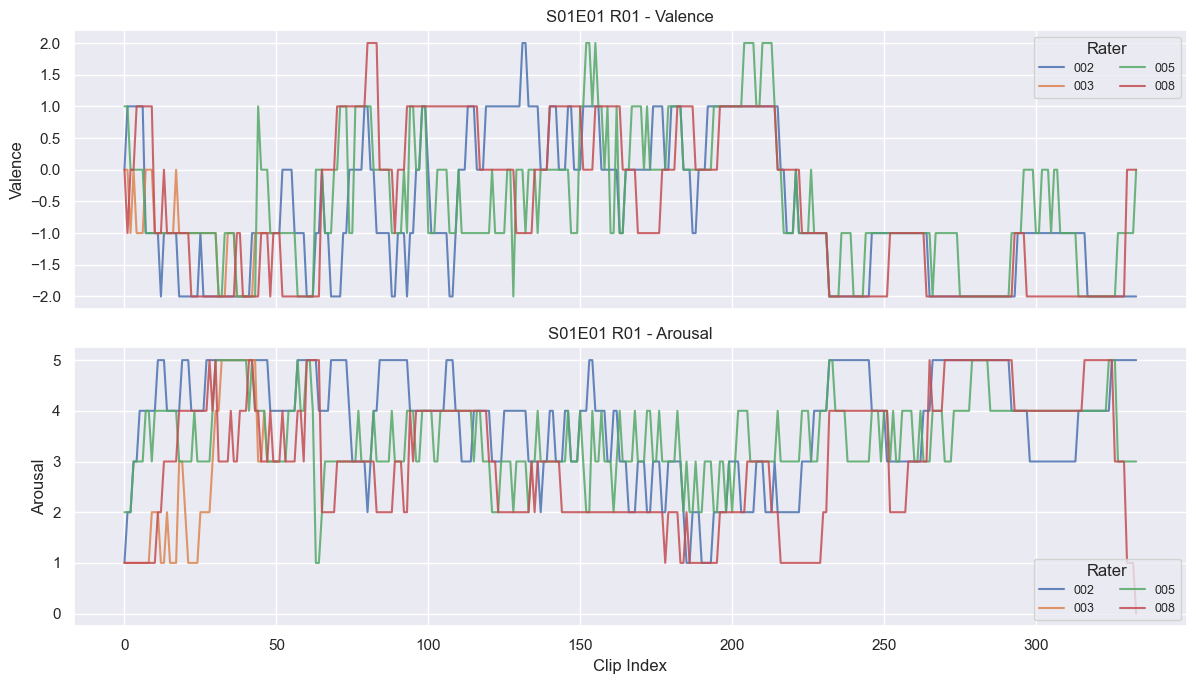

In [128]:
# Plot all raters for one run on the same valence/arousal figure
episode_to_plot = "S01E01"
run_to_plot = "R01"

run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
print(f"{episode_to_plot} {run_to_plot}: {len(run_files)} rater file(s)")

if not run_files:
    print("No files found for this episode/run.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")

        if val_col is None or aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        axes[0].plot(df[val_col].to_numpy(), label=rater_label, alpha=0.85)
        axes[1].plot(df[aro_col].to_numpy(), label=rater_label, alpha=0.85)

    axes[0].set_title(f"{episode_to_plot} {run_to_plot} - Valence")
    axes[0].set_ylabel("Valence")
    axes[0].legend(title="Rater", ncol=2, fontsize=9)

    axes[1].set_title(f"{episode_to_plot} {run_to_plot} - Arousal")
    axes[1].set_ylabel("Arousal")
    axes[1].set_xlabel("Clip Index")
    axes[1].legend(title="Rater", ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()

S01E01 R01: 4 rater file(s)
Valence ICC2 = 0.528
Arousal ICC2 = 0.37


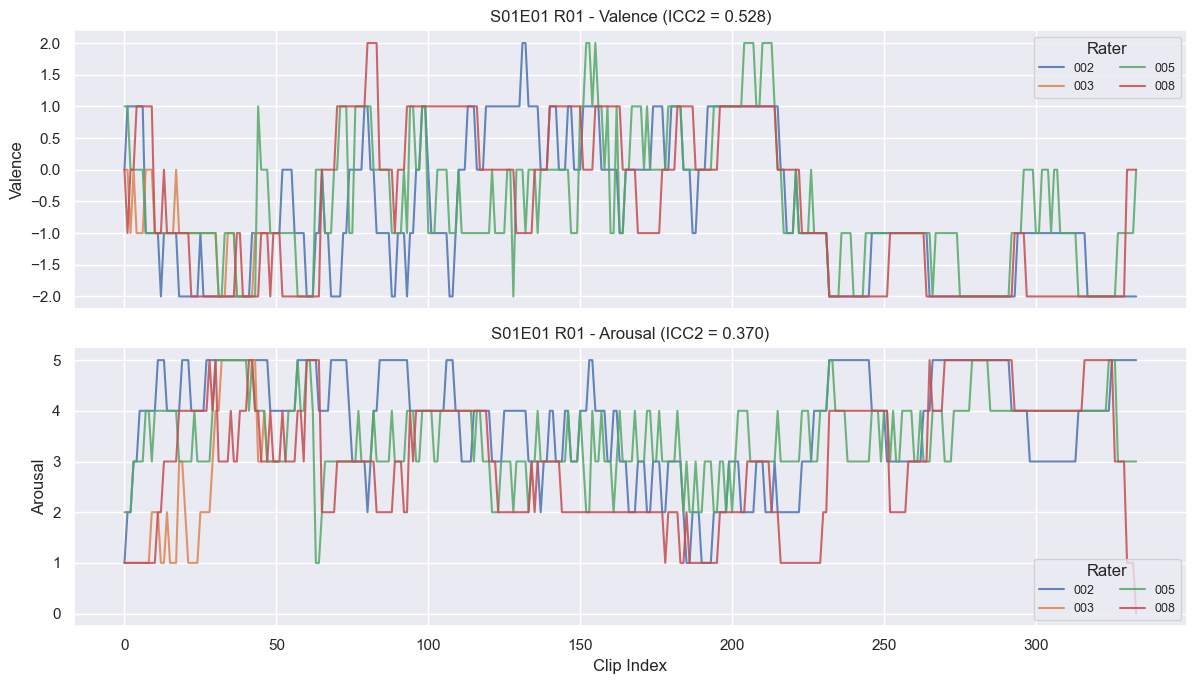

In [134]:
# Plot all raters for one run on the same valence/arousal figure
episode_to_plot = "S01E01"
run_to_plot = "R01"

run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
print(f"{episode_to_plot} {run_to_plot}: {len(run_files)} rater file(s)")

if not run_files:
    print("No files found for this episode/run.")
else:
    # -----------------------------
    # 1) Compute VALENCE ICC
    # -----------------------------
    dfs_val = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")

        if val_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        temp_val = pd.DataFrame({
            "time": np.arange(len(df)),
            "rater": rater_label,
            "valence": pd.to_numeric(df[val_col], errors="coerce")
        })

        dfs_val.append(temp_val)

    long_df_val = pd.concat(dfs_val, ignore_index=True)
    long_df_val = long_df_val.dropna()

    icc_result_val = pg.intraclass_corr(
        data=long_df_val,
        targets='time',
        raters='rater',
        ratings='valence',
        nan_policy='omit'
    )

    icc_val = icc_result_val.loc[icc_result_val["Type"] == "ICC2", "ICC"].values[0]
    print("Valence ICC2 =", round(icc_val, 3))

    # -----------------------------
    # 2) Compute AROUSAL ICC
    # -----------------------------
    dfs_aro = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        aro_col = col_lookup.get("arousal")

        if aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        temp_aro = pd.DataFrame({
            "time": np.arange(len(df)),
            "rater": rater_label,
            "arousal": pd.to_numeric(df[aro_col], errors="coerce")
        })

        dfs_aro.append(temp_aro)

    long_df_aro = pd.concat(dfs_aro, ignore_index=True)
    long_df_aro = long_df_aro.dropna()

    icc_result_aro = pg.intraclass_corr(
        data=long_df_aro,
        targets='time',
        raters='rater',
        ratings='arousal',
        nan_policy='omit'
    )

    icc_aro = icc_result_aro.loc[icc_result_aro["Type"] == "ICC2", "ICC"].values[0]
    print("Arousal ICC2 =", round(icc_aro, 3))

    # -----------------------------
    # 3) Plot
    # -----------------------------
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")

        if val_col is None or aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        axes[0].plot(df[val_col].to_numpy(), label=rater_label, alpha=0.85)
        axes[1].plot(df[aro_col].to_numpy(), label=rater_label, alpha=0.85)

    axes[0].set_title(f"{episode_to_plot} {run_to_plot} - Valence (ICC2 = {icc_val:.3f})")
    axes[0].set_ylabel("Valence")
    axes[0].legend(title="Rater", ncol=2, fontsize=9)

    axes[1].set_title(f"{episode_to_plot} {run_to_plot} - Arousal (ICC2 = {icc_aro:.3f})")
    axes[1].set_ylabel("Arousal")
    axes[1].set_xlabel("Clip Index")
    axes[1].legend(title="Rater", ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()

S01E01 R01: 4 rater file(s)
Valence ICC2 = 0.528
Arousal ICC2 = 0.37


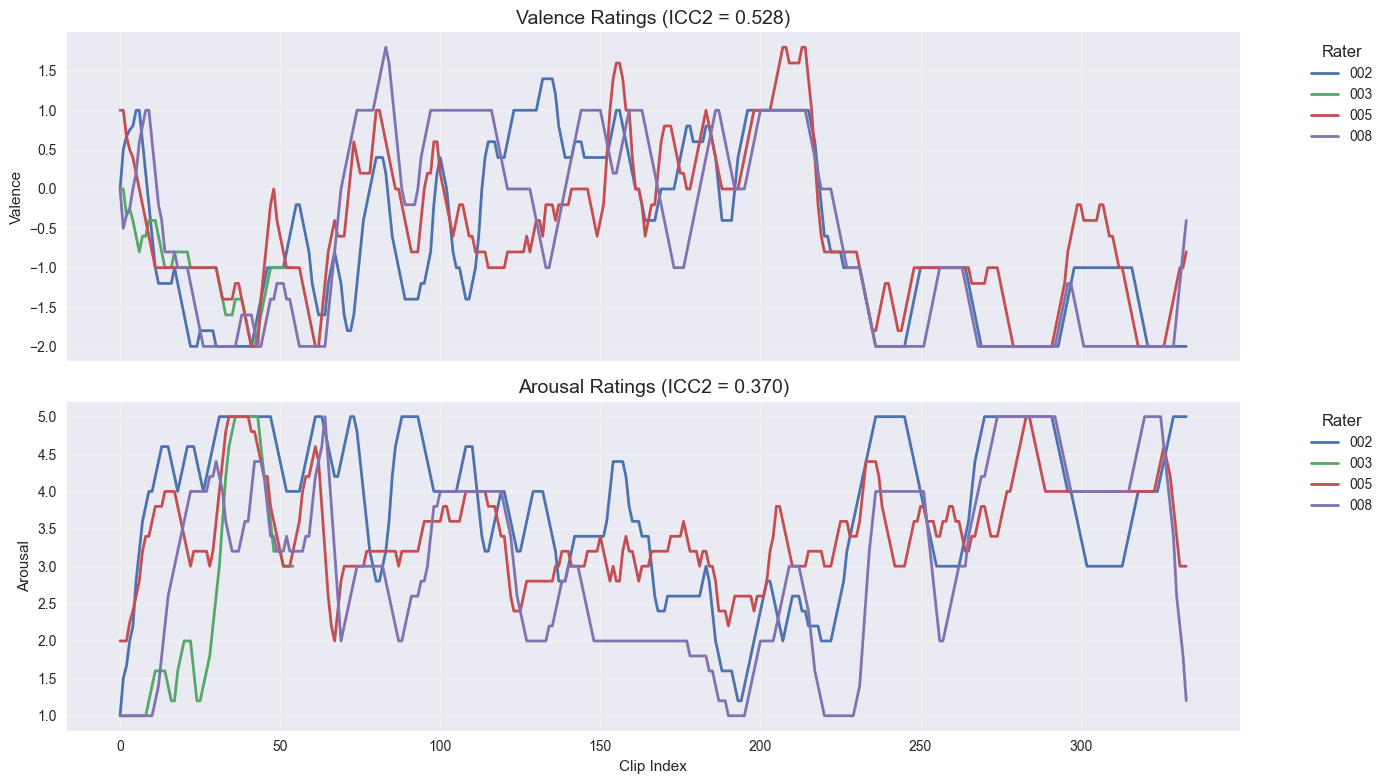

In [135]:
# Plot all raters for one run on the same valence/arousal figure
episode_to_plot = "S01E01"
run_to_plot = "R01"

plt.style.use('seaborn-v0_8')

run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
print(f"{episode_to_plot} {run_to_plot}: {len(run_files)} rater file(s)")

if not run_files:
    print("No files found for this episode/run.")
else:
    # -----------------------------
    # 1) Compute VALENCE ICC
    # -----------------------------
    dfs_val = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")

        if val_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        temp_val = pd.DataFrame({
            "time": np.arange(len(df)),
            "rater": rater_label,
            "valence": pd.to_numeric(df[val_col], errors="coerce")
        })

        dfs_val.append(temp_val)

    long_df_val = pd.concat(dfs_val, ignore_index=True)
    long_df_val = long_df_val.dropna()

    icc_result_val = pg.intraclass_corr(
        data=long_df_val,
        targets='time',
        raters='rater',
        ratings='valence',
        nan_policy='omit'
    )

    icc_val = icc_result_val.loc[icc_result_val["Type"] == "ICC2", "ICC"].values[0]
    print("Valence ICC2 =", round(icc_val, 3))

    # -----------------------------
    # 2) Compute AROUSAL ICC
    # -----------------------------
    dfs_aro = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        aro_col = col_lookup.get("arousal")

        if aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        temp_aro = pd.DataFrame({
            "time": np.arange(len(df)),
            "rater": rater_label,
            "arousal": pd.to_numeric(df[aro_col], errors="coerce")
        })

        dfs_aro.append(temp_aro)

    long_df_aro = pd.concat(dfs_aro, ignore_index=True)
    long_df_aro = long_df_aro.dropna()

    icc_result_aro = pg.intraclass_corr(
        data=long_df_aro,
        targets='time',
        raters='rater',
        ratings='arousal',
        nan_policy='omit'
    )

    icc_aro = icc_result_aro.loc[icc_result_aro["Type"] == "ICC2", "ICC"].values[0]
    print("Arousal ICC2 =", round(icc_aro, 3))

    # -----------------------------
    # 3) Plot
    # -----------------------------
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")

        if val_col is None or aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        val_series = pd.to_numeric(df[val_col], errors="coerce").rolling(5, min_periods=1).mean()
        aro_series = pd.to_numeric(df[aro_col], errors="coerce").rolling(5, min_periods=1).mean()

        axes[0].plot(val_series, label=rater_label, linewidth=2)
        axes[1].plot(aro_series, label=rater_label, linewidth=2)

    axes[0].set_title(f"Valence Ratings (ICC2 = {icc_val:.3f})", fontsize=14)
    axes[0].set_ylabel("Valence")
    axes[0].legend(title="Rater", bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title(f"Arousal Ratings (ICC2 = {icc_aro:.3f})", fontsize=14)
    axes[1].set_ylabel("Arousal")
    axes[1].set_xlabel("Clip Index")
    axes[1].legend(title="Rater", bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

S01E01 R01: 4 rater file(s)


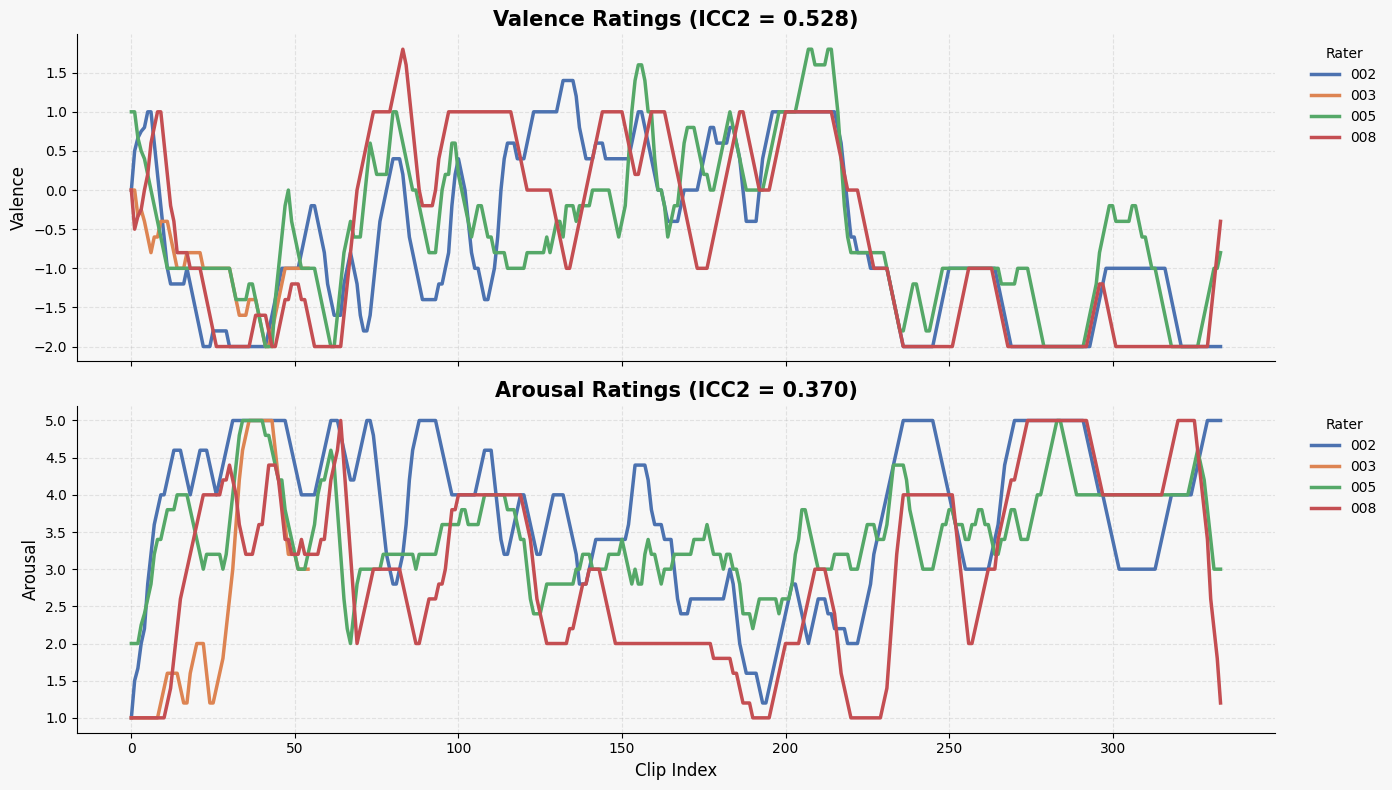

In [136]:
# Plot all raters for one run on the same valence/arousal figure
episode_to_plot = "S01E01"
run_to_plot = "R01"

# --- STYLE ---
plt.style.use('default')  # reset
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']  # nice palette

run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
print(f"{episode_to_plot} {run_to_plot}: {len(run_files)} rater file(s)")

if not run_files:
    print("No files found for this episode/run.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # soft background
    fig.patch.set_facecolor('#f7f7f7')
    axes[0].set_facecolor('#f7f7f7')
    axes[1].set_facecolor('#f7f7f7')

    for i, file_path in enumerate(run_files):
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")

        if val_col is None or aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        # smooth lines
        val_series = pd.to_numeric(df[val_col], errors="coerce").rolling(5, min_periods=1).mean()
        aro_series = pd.to_numeric(df[aro_col], errors="coerce").rolling(5, min_periods=1).mean()

        color = colors[i % len(colors)]

        axes[0].plot(val_series, label=rater_label, linewidth=2.5, color=color)
        axes[1].plot(aro_series, label=rater_label, linewidth=2.5, color=color)

    # --- TITLES ---
    axes[0].set_title(f"Valence Ratings (ICC2 = {icc_val:.3f})", fontsize=15, weight='bold')
    axes[1].set_title(f"Arousal Ratings (ICC2 = {icc_aro:.3f})", fontsize=15, weight='bold')

    # --- LABELS ---
    axes[0].set_ylabel("Valence", fontsize=12)
    axes[1].set_ylabel("Arousal", fontsize=12)
    axes[1].set_xlabel("Clip Index", fontsize=12)

    # --- GRID ---
    for ax in axes:
        ax.grid(True, linestyle='--', alpha=0.3)

    # --- LEGEND ---
    axes[0].legend(title="Rater", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    axes[1].legend(title="Rater", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    # remove top/right borders (clean look)
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

S01E01 R01: 4 rater file(s)


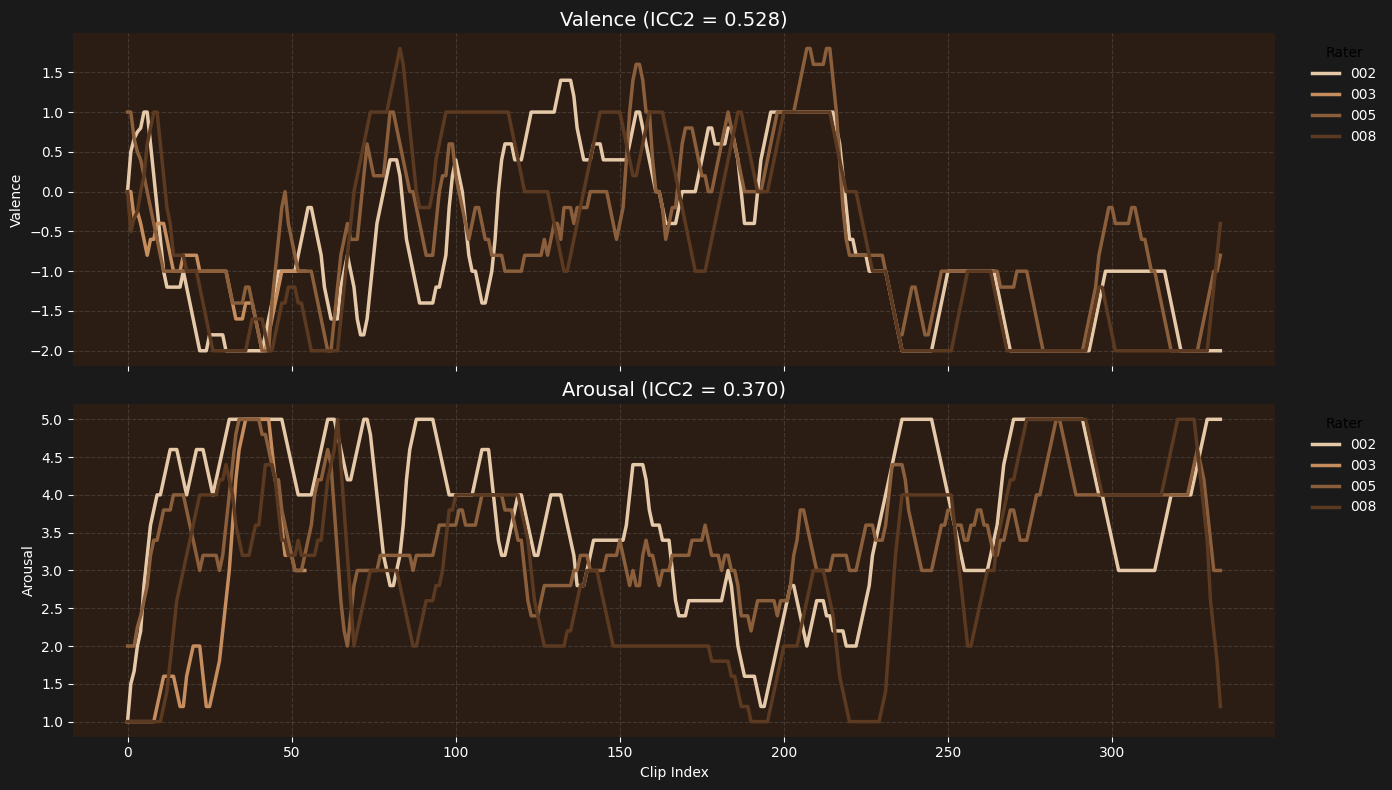

In [138]:
# Plot all raters for one run on the same valence/arousal figure
episode_to_plot = "S01E01"
run_to_plot = "R01"

# --- CUSTOM DARK STYLE ---
plt.style.use('default')

# earthy/dark palette
colors = ['#E6C9A8', '#C68E5F', '#8B5E3C', '#5C3A21', '#D9A066']

run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
print(f"{episode_to_plot} {run_to_plot}: {len(run_files)} rater file(s)")

if not run_files:
    print("No files found for this episode/run.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- BACKGROUND ---
    fig.patch.set_facecolor('#1a1a1a')        # overall background (black)
    axes[0].set_facecolor('#2b1d14')          # dark brown
    axes[1].set_facecolor('#2b1d14')

    for i, file_path in enumerate(run_files):
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")

        if val_col is None or aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        # smooth lines
        val_series = pd.to_numeric(df[val_col], errors="coerce").rolling(5, min_periods=1).mean()
        aro_series = pd.to_numeric(df[aro_col], errors="coerce").rolling(5, min_periods=1).mean()

        color = colors[i % len(colors)]

        axes[0].plot(val_series, label=rater_label, linewidth=2.5, color=color)
        axes[1].plot(aro_series, label=rater_label, linewidth=2.5, color=color)

    # --- TITLES ---
    axes[0].set_title(f"Valence (ICC2 = {icc_val:.3f})", fontsize=14, color='white')
    axes[1].set_title(f"Arousal (ICC2 = {icc_aro:.3f})", fontsize=14, color='white')

    # --- LABELS ---
    axes[0].set_ylabel("Valence", color='white')
    axes[1].set_ylabel("Arousal", color='white')
    axes[1].set_xlabel("Clip Index", color='white')

    # --- TICKS ---
    for ax in axes:
        ax.tick_params(colors='white')

    # --- GRID ---
    for ax in axes:
        ax.grid(True, linestyle='--', alpha=0.2, color='#aaaaaa')

    # --- LEGEND ---
    axes[0].legend(title="Rater", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, labelcolor='white')
    axes[1].legend(title="Rater", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, labelcolor='white')

    # --- REMOVE BORDERS ---
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    plt.show()

S01E01 R01: 4 rater file(s)


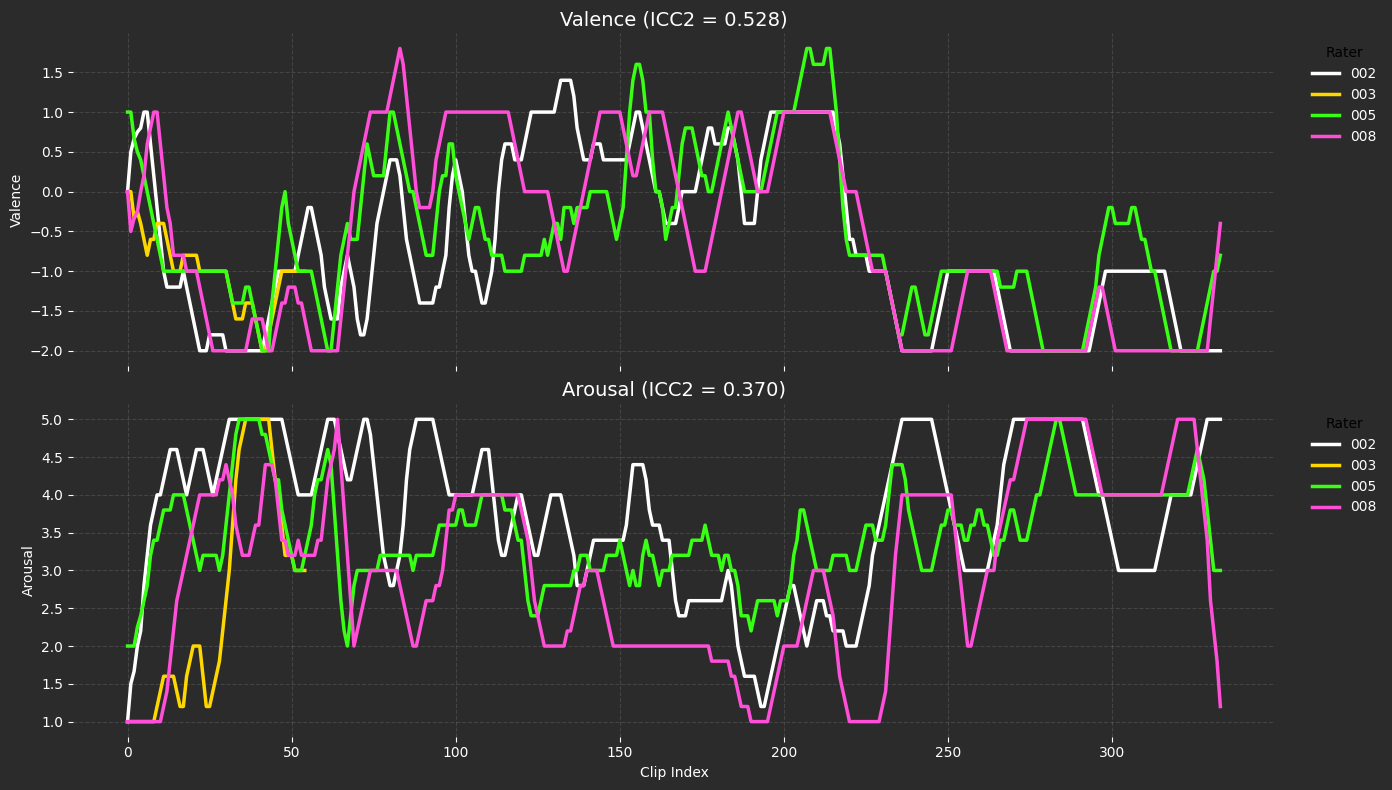

In [141]:
# Plot all raters for one run on the same valence/arousal figure
episode_to_plot = "S01E01"
run_to_plot = "R01"

plt.style.use('default')

# --- CUSTOM COLORS (exactly what you asked) ---
colors = ['#FFFFFF', '#FFD700', '#39FF14', '#FF4FD8']  
# white, gold, neon green, pink/purple

run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
print(f"{episode_to_plot} {run_to_plot}: {len(run_files)} rater file(s)")

if not run_files:
    print("No files found for this episode/run.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- BACKGROUND ---
    fig.patch.set_facecolor('#2b2b2b')     # dark gray
    axes[0].set_facecolor('#2b2b2b')
    axes[1].set_facecolor('#2b2b2b')

    for i, file_path in enumerate(run_files):
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")

        if val_col is None or aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        # smooth lines
        val_series = pd.to_numeric(df[val_col], errors="coerce").rolling(5, min_periods=1).mean()
        aro_series = pd.to_numeric(df[aro_col], errors="coerce").rolling(5, min_periods=1).mean()

        color = colors[i % len(colors)]

        axes[0].plot(val_series, label=rater_label, linewidth=2.5, color=color)
        axes[1].plot(aro_series, label=rater_label, linewidth=2.5, color=color)

    # --- TITLES ---
    axes[0].set_title(f"Valence (ICC2 = {icc_val:.3f})", fontsize=14, color='white')
    axes[1].set_title(f"Arousal (ICC2 = {icc_aro:.3f})", fontsize=14, color='white')

    # --- LABELS ---
    axes[0].set_ylabel("Valence", color='white')
    axes[1].set_ylabel("Arousal", color='white')
    axes[1].set_xlabel("Clip Index", color='white')

    # --- TICKS ---
    for ax in axes:
        ax.tick_params(colors='white')

    # --- GRID ---
    for ax in axes:
        ax.grid(True, linestyle='--', alpha=0.2, color='#aaaaaa')

    # --- LEGEND ---
    axes[0].legend(title="Rater", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, labelcolor='white')
    axes[1].legend(title="Rater", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, labelcolor='white')

    # --- REMOVE BORDERS ---
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    plt.show()

S01E01 R02: 5 rater file(s)
Valence ICC2 = 0.628
Arousal ICC2 = 0.276


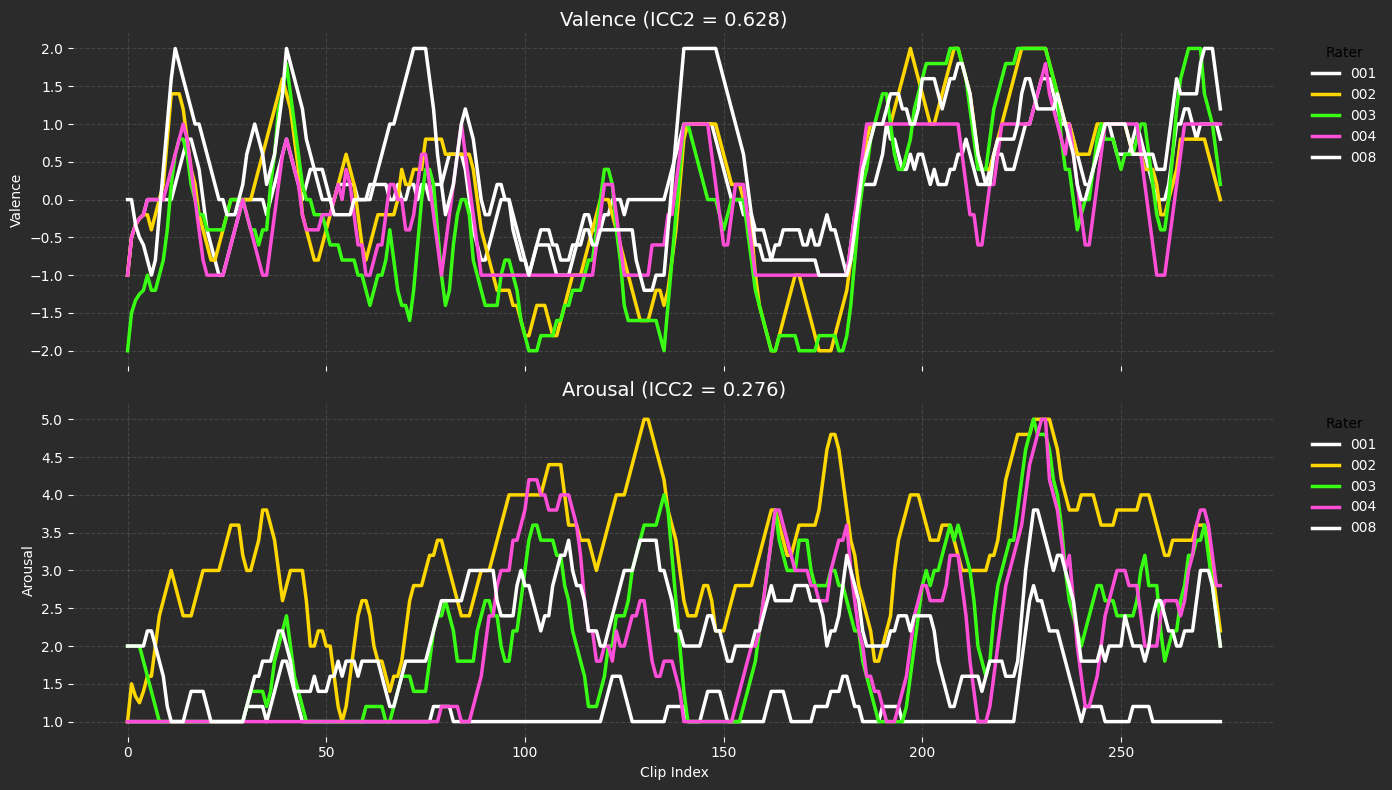

In [ ]:
# Plot all raters for one run on the same valence/arousal figure
episode_to_plot = "S01E01"
run_to_plot = "R02"

plt.style.use('default')

# --- CUSTOM COLORS ---
colors = ['#FFFFFF', '#FFD700', '#39FF14', '#FF4FD8']  
# white, gold, neon green, pink/purple

run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
print(f"{episode_to_plot} {run_to_plot}: {len(run_files)} rater file(s)")

if not run_files:
    print("No files found for this episode/run.")
else:
    # -----------------------------
    # 1) Compute VALENCE ICC for THIS run
    # -----------------------------
    dfs_val = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")

        if val_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        temp_val = pd.DataFrame({
            "time": np.arange(len(df)),
            "rater": rater_label,
            "valence": pd.to_numeric(df[val_col], errors="coerce")
        })

        dfs_val.append(temp_val)

    long_df_val = pd.concat(dfs_val, ignore_index=True).dropna()

    icc_result_val = pg.intraclass_corr(
        data=long_df_val,
        targets='time',
        raters='rater',
        ratings='valence',
        nan_policy='omit'
    )

    icc_val = icc_result_val.loc[icc_result_val["Type"] == "ICC2", "ICC"].values[0]
    print("Valence ICC2 =", round(icc_val, 3))

    # -----------------------------
    # 2) Compute AROUSAL ICC for THIS run
    # -----------------------------
    dfs_aro = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        aro_col = col_lookup.get("arousal")

        if aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        temp_aro = pd.DataFrame({
            "time": np.arange(len(df)),
            "rater": rater_label,
            "arousal": pd.to_numeric(df[aro_col], errors="coerce")
        })

        dfs_aro.append(temp_aro)

    long_df_aro = pd.concat(dfs_aro, ignore_index=True).dropna()

    icc_result_aro = pg.intraclass_corr(
        data=long_df_aro,
        targets='time',
        raters='rater',
        ratings='arousal',
        nan_policy='omit'
    )

    icc_aro = icc_result_aro.loc[icc_result_aro["Type"] == "ICC2", "ICC"].values[0]
    print("Arousal ICC2 =", round(icc_aro, 3))

    # -----------------------------
    # 3) Plot
    # -----------------------------
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # background
    fig.patch.set_facecolor('#2b2b2b')
    axes[0].set_facecolor('#2b2b2b')
    axes[1].set_facecolor('#2b2b2b')

    for i, file_path in enumerate(run_files):
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")

        if val_col is None or aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        val_series = pd.to_numeric(df[val_col], errors="coerce").rolling(5, min_periods=1).mean()
        aro_series = pd.to_numeric(df[aro_col], errors="coerce").rolling(5, min_periods=1).mean()

        color = colors[i % len(colors)]

        axes[0].plot(val_series, label=rater_label, linewidth=2.5, color=color)
        axes[1].plot(aro_series, label=rater_label, linewidth=2.5, color=color)

    axes[0].set_title(f"Valence (ICC2 = {icc_val:.3f})", fontsize=14, color='white')
    axes[1].set_title(f"Arousal (ICC2 = {icc_aro:.3f})", fontsize=14, color='white')

    axes[0].set_ylabel("Valence", color='white')
    axes[1].set_ylabel("Arousal", color='white')
    axes[1].set_xlabel("Clip Index", color='white')

    for ax in axes:
        ax.tick_params(colors='white')
        ax.grid(True, linestyle='--', alpha=0.2, color='#aaaaaa')

    axes[0].legend(title="Rater", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, labelcolor='white')
    axes[1].legend(title="Rater", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, labelcolor='white')

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    plt.show()

S01E01 R02: 5 rater file(s)
Valence ICC2 = 0.628
Arousal ICC2 = 0.276


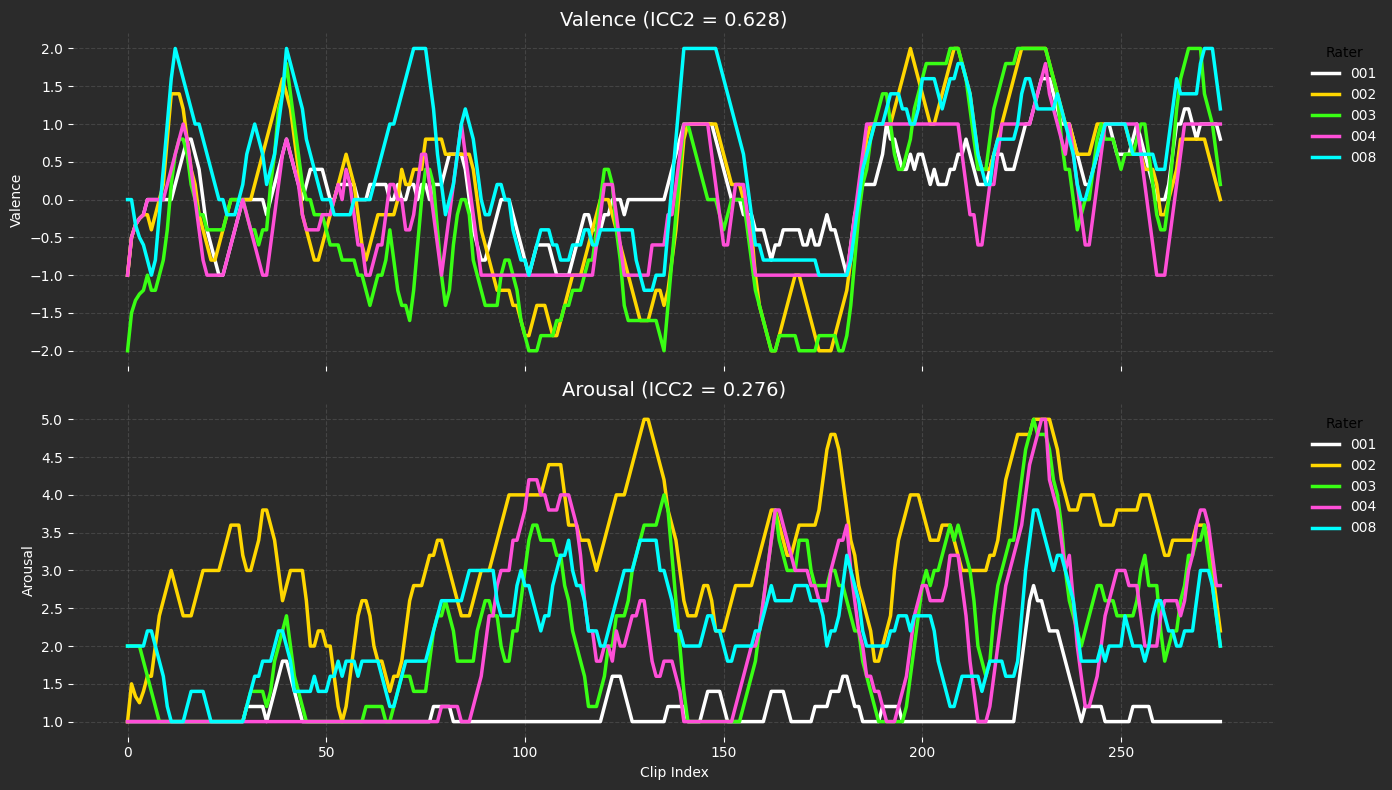

In [167]:
# Plot all raters for one run on the same valence/arousal figure
episode_to_plot = "S01E01"
run_to_plot = "R02"

plt.style.use('default')

# --- CUSTOM COLORS ---
colors = colors = ['#FFFFFF', '#FFD700', '#39FF14', '#FF4FD8', '#00FFFF']  
# white, gold, neon green, pink/purple

run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
print(f"{episode_to_plot} {run_to_plot}: {len(run_files)} rater file(s)")

if not run_files:
    print("No files found for this episode/run.")
else:
    # -----------------------------
    # 1) Compute VALENCE ICC for THIS run
    # -----------------------------
    dfs_val = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")

        if val_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        temp_val = pd.DataFrame({
            "time": np.arange(len(df)),
            "rater": rater_label,
            "valence": pd.to_numeric(df[val_col], errors="coerce")
        })

        dfs_val.append(temp_val)

    long_df_val = pd.concat(dfs_val, ignore_index=True).dropna()

    icc_result_val = pg.intraclass_corr(
        data=long_df_val,
        targets='time',
        raters='rater',
        ratings='valence',
        nan_policy='omit'
    )

    icc_val = icc_result_val.loc[icc_result_val["Type"] == "ICC2", "ICC"].values[0]
    print("Valence ICC2 =", round(icc_val, 3))

    # -----------------------------
    # 2) Compute AROUSAL ICC for THIS run
    # -----------------------------
    dfs_aro = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        aro_col = col_lookup.get("arousal")

        if aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        temp_aro = pd.DataFrame({
            "time": np.arange(len(df)),
            "rater": rater_label,
            "arousal": pd.to_numeric(df[aro_col], errors="coerce")
        })

        dfs_aro.append(temp_aro)

    long_df_aro = pd.concat(dfs_aro, ignore_index=True).dropna()

    icc_result_aro = pg.intraclass_corr(
        data=long_df_aro,
        targets='time',
        raters='rater',
        ratings='arousal',
        nan_policy='omit'
    )

    icc_aro = icc_result_aro.loc[icc_result_aro["Type"] == "ICC2", "ICC"].values[0]
    print("Arousal ICC2 =", round(icc_aro, 3))

    # -----------------------------
    # 3) Plot
    # -----------------------------
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # background
    fig.patch.set_facecolor('#2b2b2b')
    axes[0].set_facecolor('#2b2b2b')
    axes[1].set_facecolor('#2b2b2b')

    for i, file_path in enumerate(run_files):
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")

        if val_col is None or aro_col is None:
            continue

        filename = op.basename(file_path)
        rater_label = filename.split("_")[-1].replace(".csv", "")

        val_series = pd.to_numeric(df[val_col], errors="coerce").rolling(5, min_periods=1).mean()
        aro_series = pd.to_numeric(df[aro_col], errors="coerce").rolling(5, min_periods=1).mean()

        color = colors[i % len(colors)]

        axes[0].plot(val_series, label=rater_label, linewidth=2.5, color=color)
        axes[1].plot(aro_series, label=rater_label, linewidth=2.5, color=color)

    axes[0].set_title(f"Valence (ICC2 = {icc_val:.3f})", fontsize=14, color='white')
    axes[1].set_title(f"Arousal (ICC2 = {icc_aro:.3f})", fontsize=14, color='white')

    axes[0].set_ylabel("Valence", color='white')
    axes[1].set_ylabel("Arousal", color='white')
    axes[1].set_xlabel("Clip Index", color='white')

    for ax in axes:
        ax.tick_params(colors='white')
        ax.grid(True, linestyle='--', alpha=0.2, color='#aaaaaa')

    axes[0].legend(title="Rater", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, labelcolor='white')
    axes[1].legend(title="Rater", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, labelcolor='white')

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    plt.show()